In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
input_csv = "/content/drive/MyDrive/CREATE Lab/video_agent360/features_person_slot0.csv"
df=pd.read_csv(input_csv)
df.head()

,frame_idx,t,face_detected,pose_detected,yaw_proxy,pitch_proxy,smile_score,mouth_open_score,left_wrist_x,left_wrist_y,right_wrist_x,right_wrist_y,left_wrist_vis,right_wrist_vis,left_elbow_y,right_elbow_y,left_shoulder_y,right_shoulder_y,left_wrist_speed,right_wrist_speed
0,0,0.000000,1,1,-0.057497,0.519073,0.278825,0.000337,0.757487,0.893516,0.387767,0.884817,0.962057,0.904021,0.788185,0.796503,0.645804,0.643382,NaN,NaN
1,1,0.068573,1,1,0.049977,0.537860,0.260075,0.003409,0.757570,0.894371,0.387086,0.884805,0.961785,0.908736,0.792723,0.818933,0.646995,0.650322,0.012520,0.009935
2,2,0.137146,1,1,0.086832,0.538086,0.265799,0.006043,0.757565,0.894409,0.387183,0.888227,0.962980,0.914336,0.797840,0.833551,0.648109,0.654350,0.000556,0.049931
3,3,0.205719,1,1,0.091030,0.554598,0.259694,0.005194,0.740058,0.883029,0.386403,0.888538,0.961414,0.913000,0.811772,0.840716,0.648222,0.657004,0.304501,0.012248
4,4,0.274292,1,1,0.125500,0.554111,0.262697,0.006194,0.706773,0.883450,0.397098,0.895335,0.900041,0.850794,0.841276,0.859912,0.648983,0.657268,0.485431,0.184798


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# for missing value
# =========================
for col in [
    "yaw_proxy", "pitch_proxy", "smile_score", "mouth_open_score",
    "left_wrist_x", "left_wrist_y", "right_wrist_x", "right_wrist_y",
    "left_wrist_speed", "right_wrist_speed"
]:
    if col in df.columns:
        df[col] = df[col].interpolate(limit_direction="both")

# =========================
# 2. head / face behavior flags
# =========================
df["look_down_flag"] = df["pitch_proxy"] > 1.15
df["look_up_flag"] = df["pitch_proxy"] < 0.85
df["turn_left_flag"] = df["yaw_proxy"] < -0.08
df["turn_right_flag"] = df["yaw_proxy"] > 0.08

# nodding: within the rolling window, pitch moves a lot..?
window = 15   # about 0.5s, if 30fps
df["pitch_range"] = (
    df["pitch_proxy"].rolling(window, min_periods=5).max()
    - df["pitch_proxy"].rolling(window, min_periods=5).min()
)
df["head_nodding_flag"] = df["pitch_range"] > 0.18

# smile / speaking
df["smiling_flag"] = df["smile_score"] > 0.42
df["speaking_like_flag"] = df["mouth_open_score"] > 0.08

# =========================
# 3. hand / note-taking behavior
# =========================
df["hand_near_bottom"] = (
    (df["left_wrist_y"] > 0.65) |
    (df["right_wrist_y"] > 0.65)
)

df["hand_moving"] = (
    (df["left_wrist_speed"] > 0.02) |
    (df["right_wrist_speed"] > 0.02)
)

df["take_notes_flag"] = (
    df["look_down_flag"] &
    df["hand_near_bottom"] &
    df["hand_moving"]
)



###### engagement score setting


df["engagement_score"] = 0.0

df.loc[df["face_detected"] == 1, "engagement_score"] += 0.2
df.loc[df["pose_detected"] == 1, "engagement_score"] += 0.1
df.loc[df["head_nodding_flag"], "engagement_score"] += 0.2
df.loc[df["speaking_like_flag"], "engagement_score"] += 0.2
df.loc[df["smiling_flag"], "engagement_score"] += 0.1
df.loc[df["look_down_flag"], "engagement_score"] -= 0.1
df.loc[df["take_notes_flag"], "engagement_score"] += 0.1

df["engagement_score"] = df["engagement_score"].clip(0, 1)

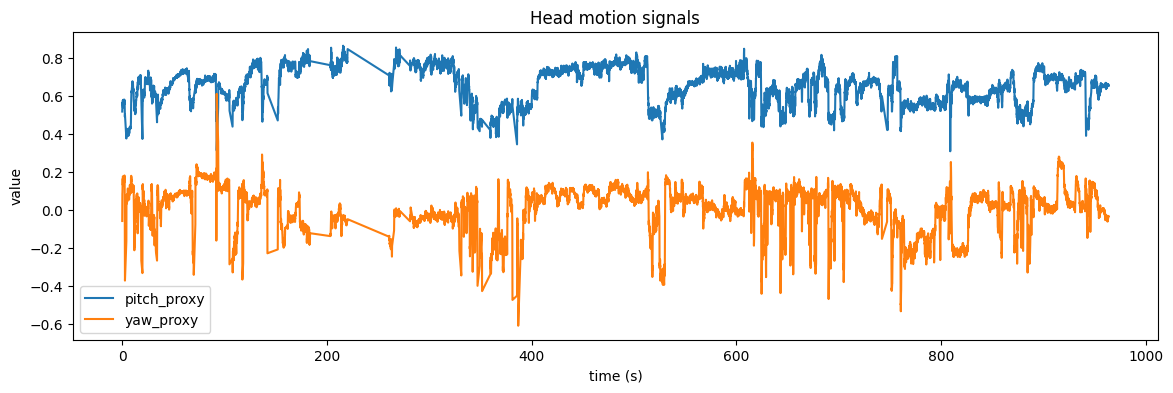

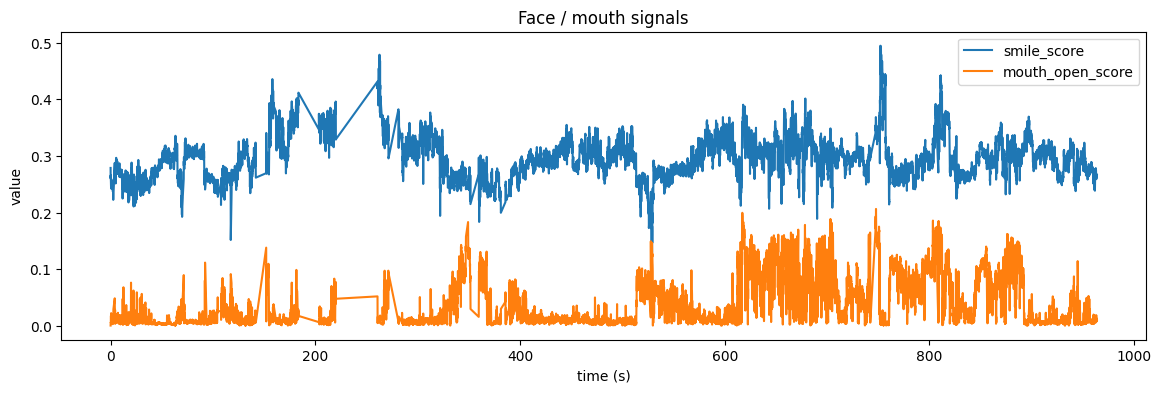

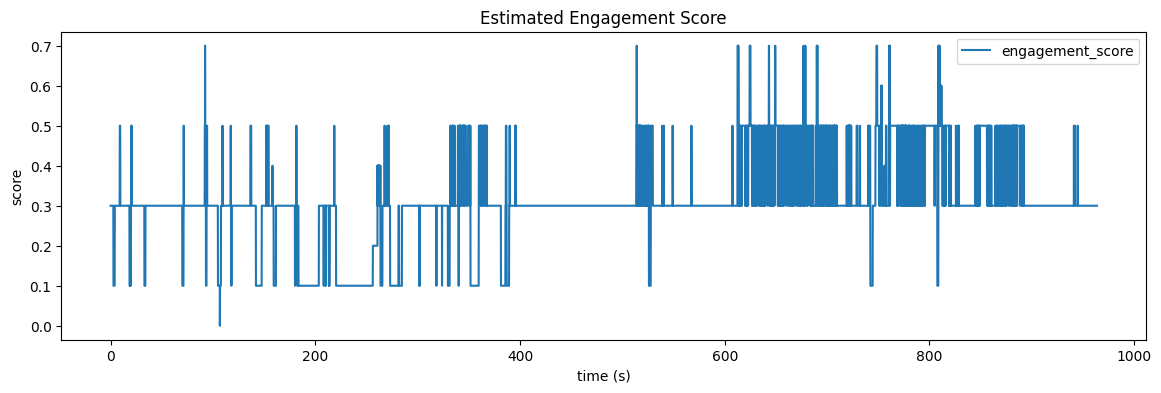

In [8]:

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["pitch_proxy"], label="pitch_proxy")
plt.plot(df["t"], df["yaw_proxy"], label="yaw_proxy")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("value")
plt.title("Head motion signals")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["smile_score"], label="smile_score")
plt.plot(df["t"], df["mouth_open_score"], label="mouth_open_score")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("value")
plt.title("Face / mouth signals")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["t"], df["engagement_score"], label="engagement_score")
plt.xlabel("time (s)")
plt.ylabel("score")
plt.title("Estimated Engagement Score")
plt.legend()
plt.show()

In [10]:
output_csv = "video_agent360/features_with_behavior_slot0.csv"
Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_csv, index=False)

print("saved to:", output_csv)
print(df.head())

saved to: video_agent360/features_with_behavior_slot0.csv
   frame_idx         t  face_detected  pose_detected  yaw_proxy  pitch_proxy  \
0          0  0.000000              1              1  -0.057497     0.519073   
1          1  0.068573              1              1   0.049977     0.537860   
2          2  0.137146              1              1   0.086832     0.538086   
3          3  0.205719              1              1   0.091030     0.554598   
4          4  0.274292              1              1   0.125500     0.554111   

   smile_score  mouth_open_score  left_wrist_x  left_wrist_y  ...  \
0     0.278825          0.000337      0.757487      0.893516  ...   
1     0.260075          0.003409      0.757570      0.894371  ...   
2     0.265799          0.006043      0.757565      0.894409  ...   
3     0.259694          0.005194      0.740058      0.883029  ...   
4     0.262697          0.006194      0.706773      0.883450  ...   

   turn_left_flag  turn_right_flag  pitch_rang